#### Notebook to test How to clean dFAD data with the speeds. 
- remove zero speeds
- high speeds
    - 1% are above 1 m/s of all the data
- remove dFADs with few data points or lots bad datapoints
- from the removed points also have to remove the Lat, lon, distance, time collumn,

In [1]:
import pandas as pd 
import numpy as np 
import geopandas as gpd 
import matplotlib.pyplot as plt 
from functions.funcs import *

In [2]:
data = gpd.read_file(r"Data\Palmyra Data\MI_and_SAT_FAD_positions")
NWR = gpd.read_file(r"Data/Palmyra_Shapefiles",layer = 'PAL_KING_NWR_12nm')

In [3]:
data = samplefreq(data)
data, delx_long, dely_long= add_distance_collumns(data)
data = add_time_collumns(data)
data = Add_x_y_speed_collums(data)
data= add_time_collumns(data)


c:\FATE\Code\functions\funcs.py:225: RuntimeWarning: divide by zero encountered in divide
  heading = np.atan(delx_long/dely_long)
c:\FATE\Code\functions\funcs.py:343: RuntimeWarning: divide by zero encountered in divide
  xspeed = xdistance/data.at[ i, "SampleFreq"]*convert
c:\FATE\Code\functions\funcs.py:347: RuntimeWarning: divide by zero encountered in divide
  yspeed = ydistance/data.at[ i, "SampleFreq"]*convert
c:\FATE\Code\functions\funcs.py:351: RuntimeWarning: divide by zero encountered in divide
  xyspeed = xydistance/data.at[ i, "SampleFreq"]*convert


In [4]:
data.columns

Index(['Shape_Leng', 'Set_3', 'BuoyName', 'Name_ID', 'MinOfTimes',
       'MaxOfTimes', 'MinOfDate', 'MaxOfDate', 'Yr_min', 'Mon_min', 'Day_min',
       'Yr_max', 'Mon_max', 'Day_max', 'Diff_days', 'Distance_n', 'geometry',
       'numpoints', 'SampleFreq', 'x_deg', 'y_deg', 'x_km', 'y_km', 'xy_km',
       'timelist', 'x_speed', 'y_speed', 'xy_speed'],
      dtype='object')

#### Checking how many Bad points there are

In [5]:
def Column_to_List(data, column:str):
    long_list = []
    for i in range(len(data)):
        row = data.at[i, column]
        long_list.extend(row)
    return long_list


In [6]:
#data = data.query("SampleFreq >0.1")
#data = data.reset_index()
data4h = data.query("SampleFreq >3.9").query("SampleFreq <4.1")
data4h = data4h.reset_index()
speed4h = np.array(Column_to_List(data4h,"xy_speed" ))
speed = np.array(Column_to_List(data,"xy_speed"))


In [7]:
speed4h_fast = speed4h[speed4h > 2]
speed_fast = speed[speed>2]
print(f"high speed: {len(speed_fast)/len(speed)*100}")
print(f"4h_sample high speed: {len(speed4h_fast)/len(speed4h)*100}")

high speed: 0.27412174115908783
4h_sample high speed: 0.017815255797381156


In [8]:
## slow speeds 
speed4h_slow = speed4h[speed4h<0.001]
speed_slow = speed[speed<0.001]
print(f"Slow 4h speed:{len(speed4h_slow)/len(speed4h)*100:.3}%")
print(f"Slow Speeds: {len(speed_slow)/len(speed)*100:.3}%")

Slow 4h speed:0.104%
Slow Speeds: 0.745%


In [9]:
## This is the Filterning Method
speedt = data.at[1,"xy_speed"]

speedt_high = speedt>0.4
speedt_low = speedt<0.1

masked = speedt_high | speedt_low
masked =~ masked
speedt_filtered = speedt[masked]
print(len(speedt_high), len(speedt_low), len(speedt_filtered))

123 123 106


#### Removing the Bad points 

In [10]:
def Remove_speeds_high_low(data:gpd.GeoDataFrame):
    bad_points = []
    speeds = []
    Masks = [ ]
    for i in range(len(data)):
        speed = data.at[i, "xy_speed"]
        speed_high = speed>2
        speed_low = speed < 0.001
        masked = speed_high | speed_low
        masked =~ masked
        filtered_speed = speed[masked]
        bad_point = len(speed) - len(filtered_speed)
        
        speeds.append(filtered_speed)
        bad_points.append(bad_point)
        Masks.append(masked)
    
    dataclean = data.copy()
    dataclean["xy_speed"] = speeds
    dataclean["points_removed"] = bad_points
    dataclean["Masked_array"] = Masks
    return dataclean 

In [11]:
#data = gpd.read_file(r"Data\Palmyra Data\MI_and_SAT_FAD_positions")

dataclean = Remove_speeds_high_low(data)
dataclean["points_removed"].sum()
data["numpoints"].sum()

np.int64(105309)

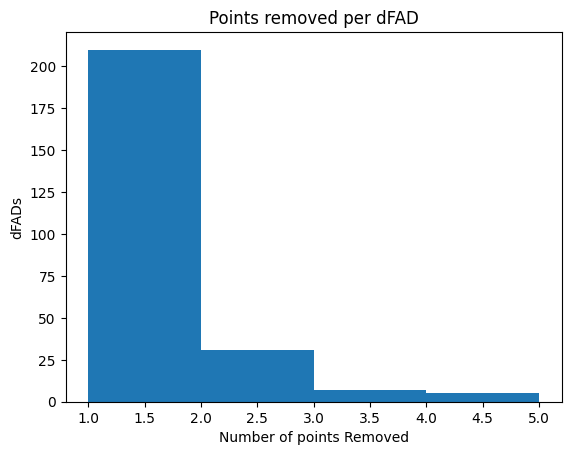

In [12]:
fig, ax = plt.subplots()
ax.hist(dataclean["points_removed"], bins= [1,2,3,4,5])
ax.set_title("Points removed per dFAD")
ax.set_xlabel("Number of points Removed")
ax.set_ylabel("dFADs")
fig.savefig("Number of Points Removed.png")

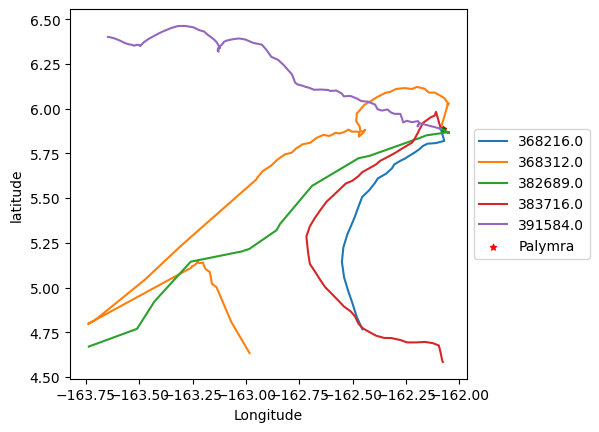

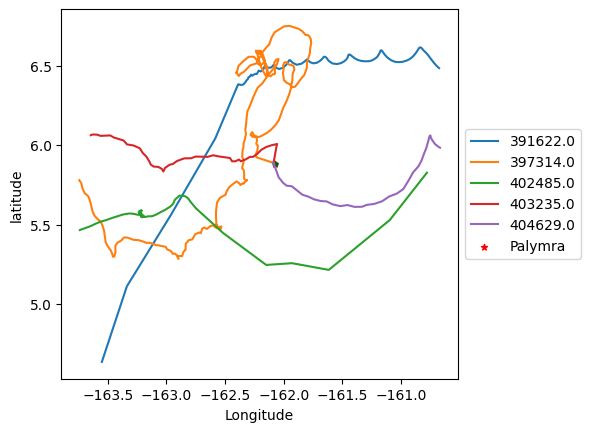

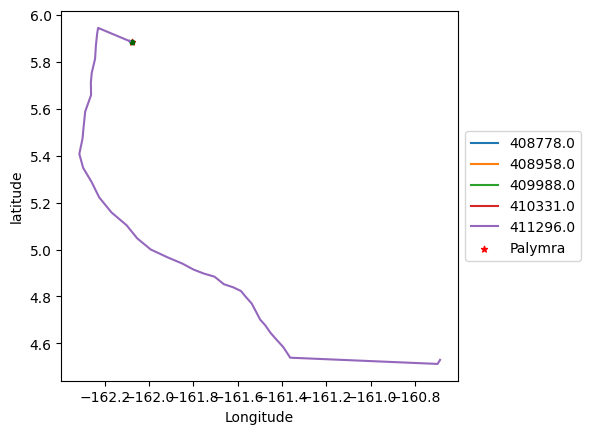

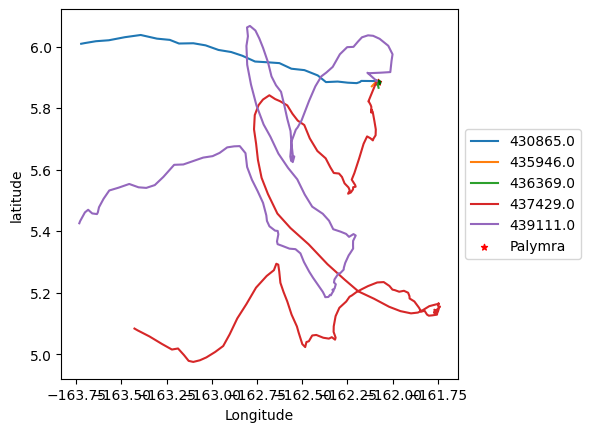

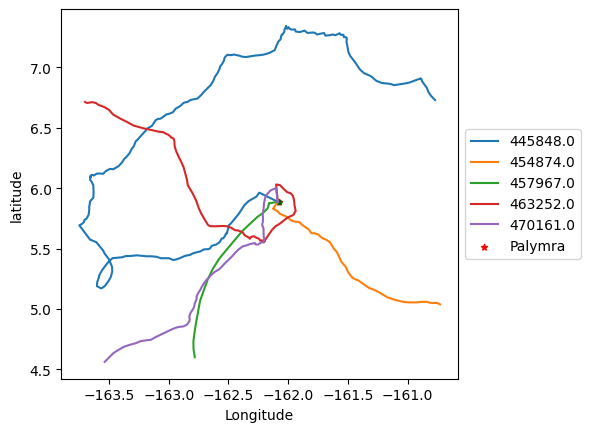

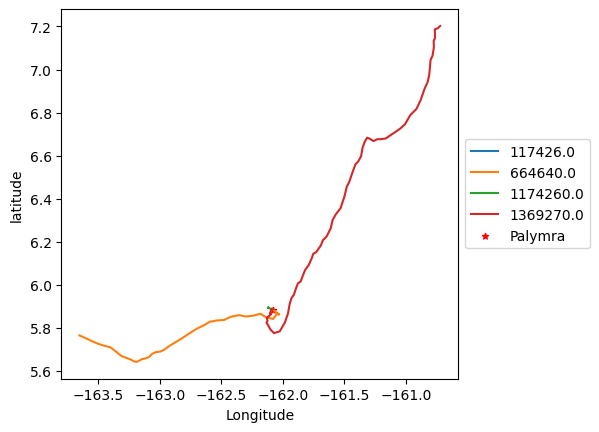

In [13]:
dataplotting = dataclean.query("points_removed > 5 ")


AllTrajectories(dataplotting,5,r"..\Figures\Cleaning Data\points10")
# OneTrajectory(ax,data,n)
# OneTrajectory(ax,dataclean,n)
# plot_NWPs(ax,NWR)

In [14]:
def Filter_geometry_obj(row):
    coords = np.asarray(row.geometry.coords)
    coords = coords[1:]
    filtered_coords = coords[row['Masked_array']]
    if len(filtered_coords) > 1:
        return sp.geometry.LineString(filtered_coords)
    else:
    # Return an empty geometry if not enough points remain
        return None

    

In [ ]:

def Filter_Rows(row,column):
    """Function implented to apply mask from bad point removal to to other columns
    if column size doesnt line up we remove the later point [1:]"""
    array =np.asarray(row[f"{column}"])
    if len(array) != len(row["Masked_array"]):
        array = array[1:]
    filtered_data = array[row["Masked_array"]]
    if len(filtered_data)>1:
        return filtered_data
    else:
        return None

In [ ]:
### Removing The bad points in Geometry 
dataclean["new_geometry"] = dataclean.apply(Filter_geometry_obj, axis = 1)
dataclean["geometry"] = dataclean["new_geometry"]
dataclean = dataclean.drop(columns = ["new_geometry"])
valid_mask = ~dataclean.geometry.isna() & ~dataclean.geometry.is_empty
dataclean = dataclean[valid_mask]

In [17]:
dataclean = dataclean.reset_index()

In [18]:
### only values where the masks dont line up are for timelist: this is one longer
counter =0
for i in range(len(dataclean)):
    a = len(dataclean["timelist"][i])
    b= len(dataclean["Masked_array"][i])
    if (a-1)!=b:
        counter += 1 
print(counter)

0


In [19]:
### Removing 

columnlist = ['x_deg', 'y_deg', 'x_km', 'y_km', 'xy_km', 'timelist' ]

for names in columnlist: 
    print(names)
    dataclean[f"new_{names}"] = dataclean.apply(Filter_Rows, axis =1, column = names)
    dataclean[f"{names}"] = dataclean[f"new_{names}"] 
    dataclean = dataclean.drop(columns = [f"new_{names}"])

x_deg
y_deg
x_km
y_km
xy_km
timelist


In [20]:
dataclean.columns

Index(['index', 'Shape_Leng', 'Set_3', 'BuoyName', 'Name_ID', 'MinOfTimes',
       'MaxOfTimes', 'MinOfDate', 'MaxOfDate', 'Yr_min', 'Mon_min', 'Day_min',
       'Yr_max', 'Mon_max', 'Day_max', 'Diff_days', 'Distance_n', 'geometry',
       'numpoints', 'SampleFreq', 'x_deg', 'y_deg', 'x_km', 'y_km', 'xy_km',
       'timelist', 'x_speed', 'y_speed', 'xy_speed', 'points_removed',
       'Masked_array', 'new_geometry'],
      dtype='object')

#### Plotting the Diffence between the trajectories

485
491
849
894
1070
1082
1231
1265
1329
1398
1483
1572
1712
1853
1864
1876
1894
1940
1975
2059
2076
2084


C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_11940\2325197553.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


2300
2315
2337


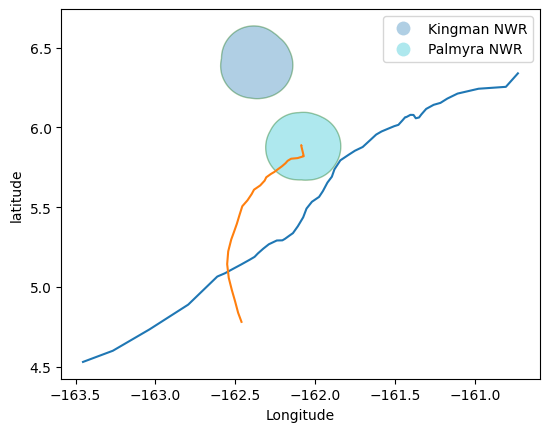

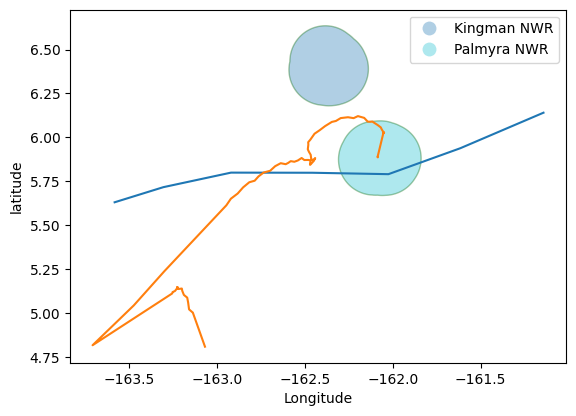

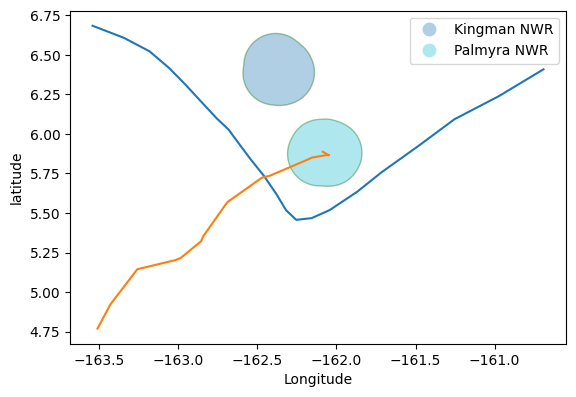

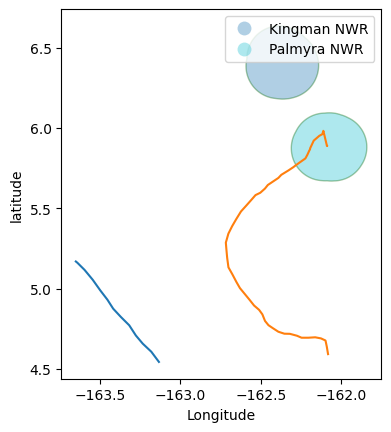

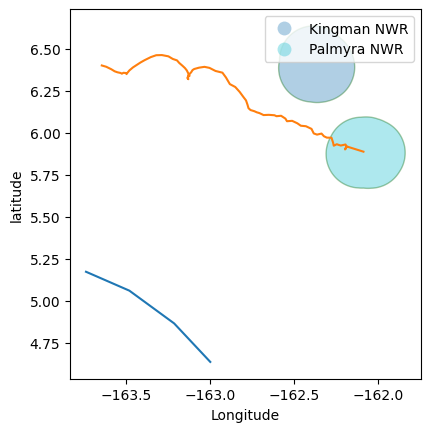

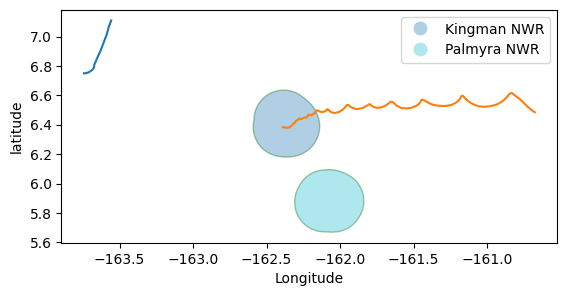

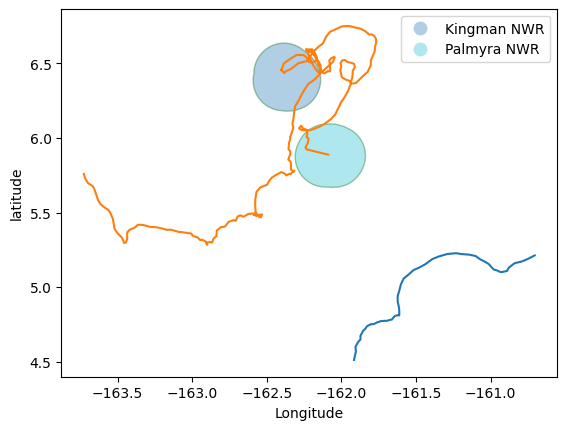

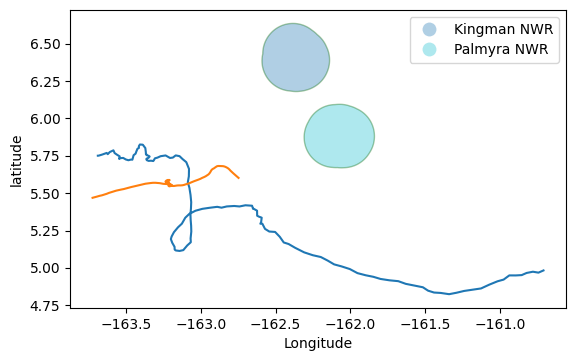

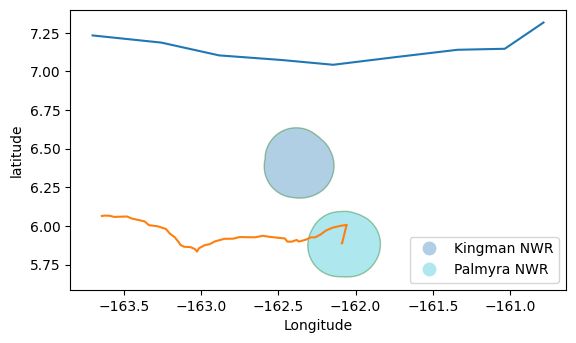

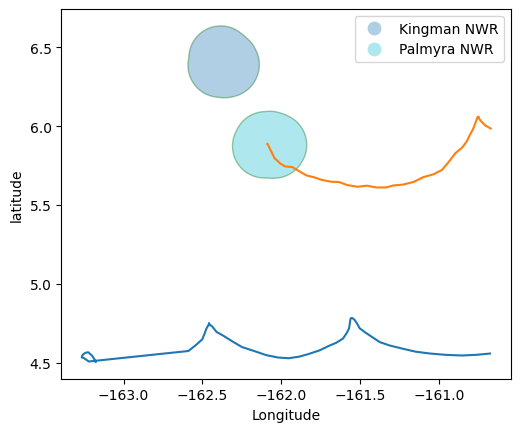

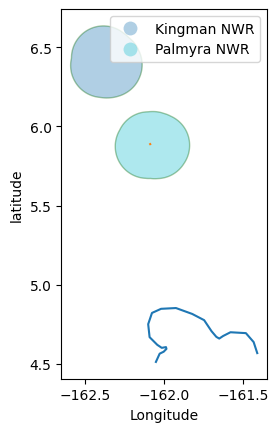

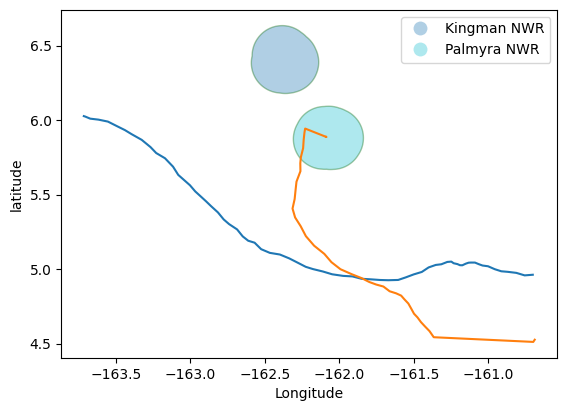

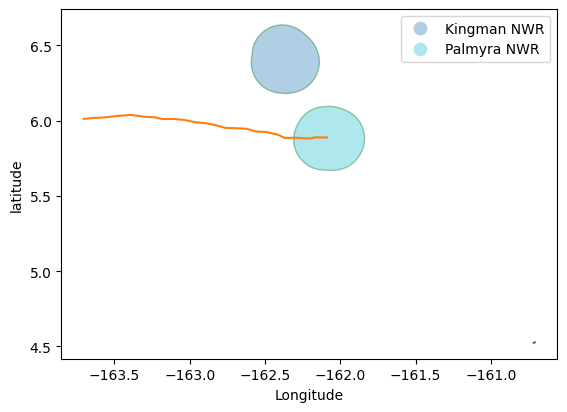

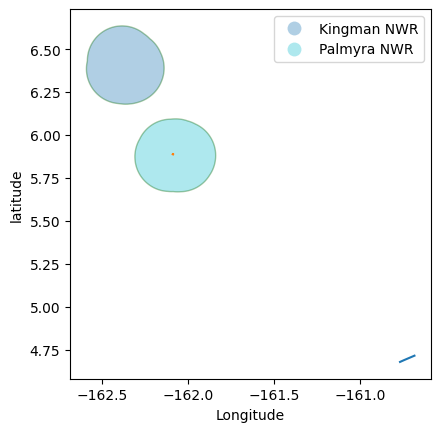

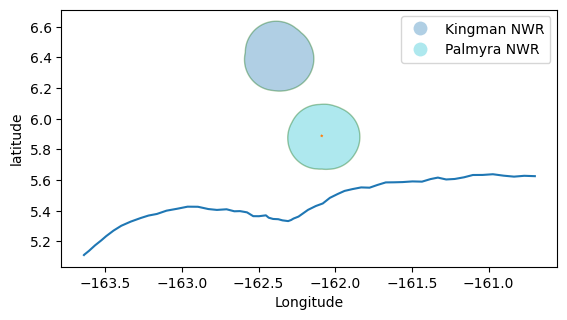

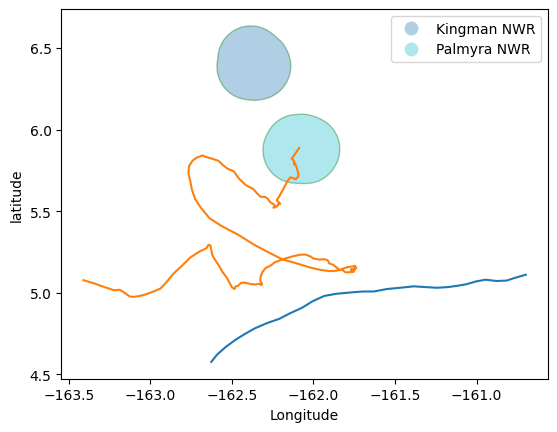

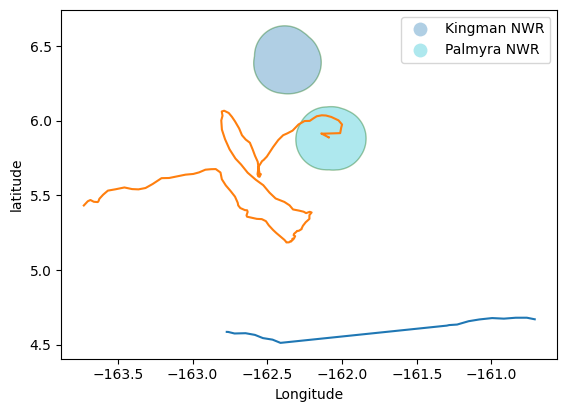

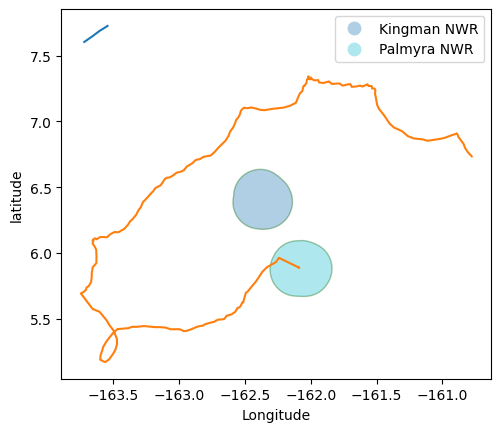

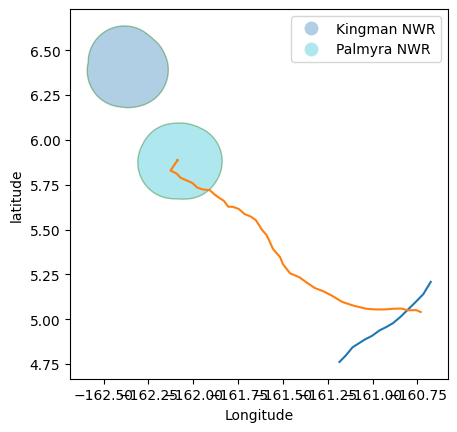

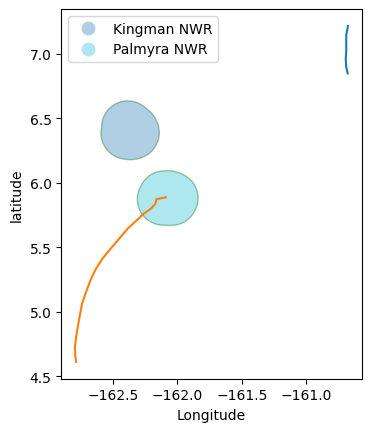

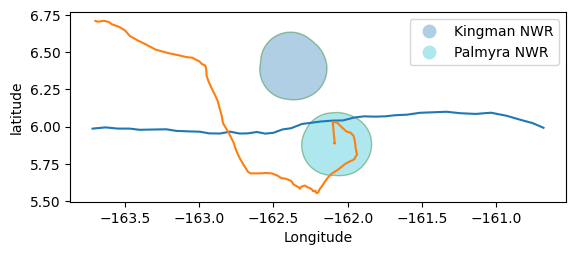

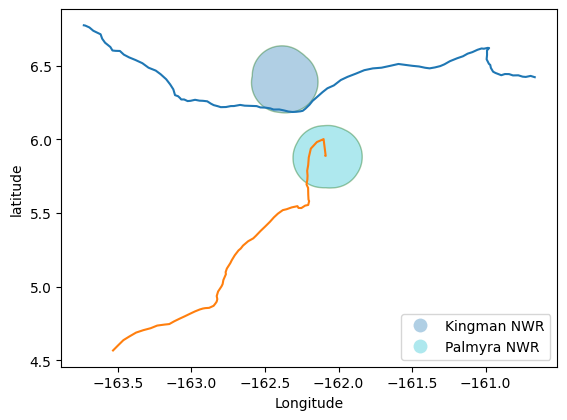

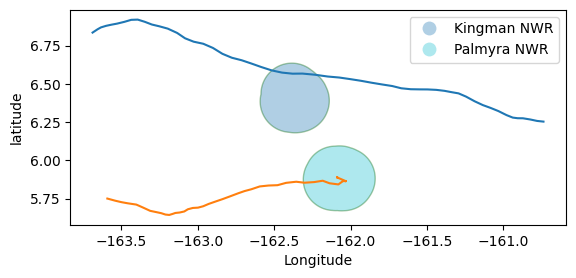

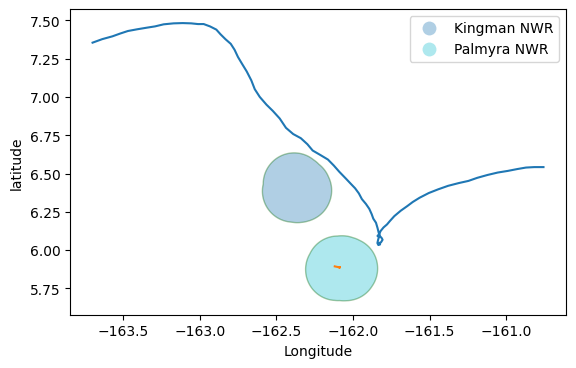

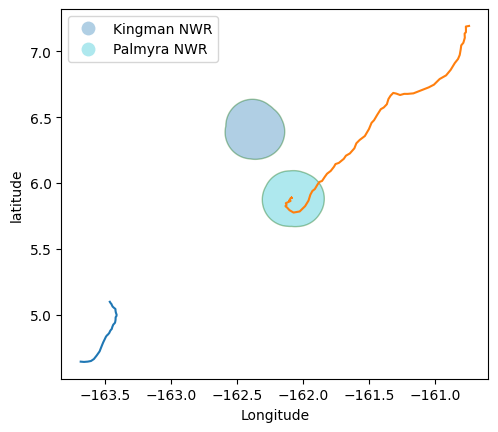

In [21]:
dataplotting = dataclean.query("points_removed > 5 ")
buoys = dataplotting["Name_ID"].unique()
for bouy in buoys:
    fig, ax = plt.subplots()
    n = dataplotting.loc[dataplotting["Name_ID"] == bouy].index.astype(int)
    print(n[0])
    OneTrajectory(ax,data,n[0])
    OneTrajectory(ax,dataclean,n[0])
    plot_NWPs(ax,NWR)
    fig.savefig(fr"..\Figures\Cleaning Data\CleanvsrawdFAD_{n[0]}.png")